# NPTEL Course: Grid Connected Power Converters - Operating Principles

## Three-Phase Converter with Conventional Space Vector PWM (CSVPWM)

**Author:** V. Seshadri Sravan Kumar, IIT Hyderabad

### Objective and Modelling Scope

The goal of this simulation is to study the switched model of a three-phase voltage-source converter interfaced with the grid using Conventional Space Vector PWM (CSVPWM). This notebook extends the single-phase studies (switching pole and H-bridge) to the three-phase case, where the converter has **three switching poles** (legs $a$, $b$, $c$) and the AC side is connected to a balanced three-phase Y-connected grid.

The DC link is assumed to be an **ideal constant voltage source**:

$$v_{dc}(t)=V_{dc}=\text{const.}$$

Hence, DC-link dynamics are not modeled. The system reduces to **three state variables**: the filter currents $i_{fa}(t)$, $i_{fb}(t)$, $i_{fc}(t)$.

### Modelling Assumptions

1. **Ideal constant DC link** — $V_{dc}$ is fixed; no capacitor dynamics.
2. **Ideal switching devices** — zero switching time, no on-state voltage drop.
3. **Balanced Y-connected grid** — the grid is a set of three stiff sinusoidal voltage sources, $v_{g,an}+v_{g,bn}+v_{g,cn}=0$.
4. **Y-connected filter without neutral wire** — the three filter currents sum to zero at all times, $i_{fa}+i_{fb}+i_{fc}=0$.
5. Saturation and higher-order parasitic effects are neglected.

### Converter Topology

Each leg $\alpha\in\{a,b,c\}$ is described by a switching function $q_\alpha(t)\in\{+1,-1\}$. The pole voltage of leg $\alpha$ with respect to the DC-link midpoint $o$ is

$$v_{\alpha o}(t)=\frac{V_{dc}}{2}\,q_\alpha(t).$$

### Governing Equations — AC Side

The voltage between the DC-link midpoint $o$ and the grid neutral $n$ is

$$v_{no}(t)=\frac{v_{ao}+v_{bo}+v_{co}}{3}=\frac{V_{dc}}{6}\big[q_a(t)+q_b(t)+q_c(t)\big].$$

The phase voltage of leg $\alpha$ with respect to the grid neutral is $v_{\alpha n}=v_{\alpha o}-v_{no}$. The KVL for each phase gives

$$L_f\frac{di_{f\alpha}}{dt}=v_{\alpha n}(t)-R_f\,i_{f\alpha}(t)-v_{g,\alpha n}(t), \qquad \alpha\in\{a,b,c\}.$$

### Governing Equation — DC Side

The DC-side current drawn from the constant voltage source is

$$i_s(t)=\frac{1}{2}\big[q_a(t)\,i_{fa}(t)+q_b(t)\,i_{fb}(t)+q_c(t)\,i_{fc}(t)\big].$$

### Modulation: Carrier-Based CSVPWM

CSVPWM is implemented in carrier-based form. The sinusoidal references $m_\alpha^*$ are augmented by a common-mode offset $m_\text{offset}$ before comparison with a triangular carrier:

$$m_a^*=M\cos(\omega_1 t),\quad m_b^*=M\cos\!\left(\omega_1 t-\frac{2\pi}{3}\right),\quad m_c^*=M\cos\!\left(\omega_1 t+\frac{2\pi}{3}\right),$$

$$m_\text{offset}=-\frac{\max(m_a^*,m_b^*,m_c^*)+\min(m_a^*,m_b^*,m_c^*)}{2},$$

$$m_\alpha=m_\alpha^*+m_\text{offset},\qquad q_\alpha(t)=\begin{cases}+1 & m_\alpha\ge c(t),\\-1 & m_\alpha<c(t).\end{cases}$$

This min-max offset injection is equivalent to centering the active-state dwell times symmetrically within each switching period, which is the hallmark of conventional (symmetric) SVPWM.

### What Is Studied in This Notebook

1. Generation of the three switching functions using carrier-based CSVPWM.
2. Time-domain waveforms of the three filter currents $i_{fa}$, $i_{fb}$, $i_{fc}$.
3. Pole voltages $v_{ao}$, $v_{bo}$, $v_{co}$ and phase voltages $v_{an}$, $v_{bn}$, $v_{cn}$.
4. DC-side current $i_s(t)$.
5. Harmonic spectrum and THD of the pole voltage and the injected current.

In [1]:
# Importing required packages

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Plotting style settings (applied globally to all subsequent plots)
plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['font.size']         = 10
#
plt.rcParams['axes.spines.top']   = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['ytick.direction']   = 'in'

### System Parameters

The parameter values below represent a three-phase grid-connected converter rated at approximately 5 kW, connected to a 415 V (line-to-line RMS), 50 Hz grid.

With CSVPWM, the maximum fundamental peak phase voltage is $V_{dc}/\sqrt{3}$, so $V_{dc}$ must satisfy $V_{dc}\ge\sqrt{3}\,\sqrt{2}\,V_{g,\text{LL,rms}}/M$. The chosen value of 700 V gives headroom for the modulation index used here.

The variable `pwm_mode` selects between CSVPWM (with min-max offset) and plain SPWM (no offset) for comparison.

In [2]:
Vg_ll_rms = 415.0          # grid line-to-line RMS voltage (V)
Vg_rms    = Vg_ll_rms / np.sqrt(3)   # grid phase RMS voltage (V)
f1        = 50.0           # grid fundamental frequency (Hz)

Vdc       = 700.0          # DC link voltage (V), fixed

M         = 0.85           # modulation index
phi_m     = np.pi/2        # phase of modulating signal, radians (cosine reference)

fsw       = 5000.0         # switching frequency (Hz)
m_f       = fsw / f1       # carrier ratio

Lf        = 10e-3          # filter inductance (H)
Rf        = 0.1            # filter resistance (ohm)

pwm_mode  = 'csvpwm'       # 'csvpwm' (with min-max offset) or 'spwm' (no offset)

print(f"Grid phase voltage (RMS): {Vg_rms:.1f} V")
print(f"Grid phase voltage (peak): {np.sqrt(2)*Vg_rms:.1f} V")
print(f"Carrier ratio m_f = {m_f:.0f}")
print(f"Max linear peak phase voltage (CSVPWM): {Vdc/np.sqrt(3):.1f} V")
print(f"Commanded peak phase voltage: {M*Vdc/2:.1f} V")

Grid phase voltage (RMS): 239.6 V
Grid phase voltage (peak): 338.8 V
Carrier ratio m_f = 100
Max linear peak phase voltage (CSVPWM): 404.1 V
Commanded peak phase voltage: 297.5 V


### Time Discretization

The sampling interval is chosen from the required number of points per switching period. A sufficient number of samples per switching cycle helps capture ripple clearly and accurately.

In [3]:
n_cycles      = 4                             # number of fundamental cycles to simulate
n_pts_per_Tsw = 40                            # number of time instants per switching cycle

t_end         = n_cycles / f1                 # total simulation time (s)
t_step        = (1.0 / fsw) / n_pts_per_Tsw   # time step (s)

t             = np.arange(0, t_end, t_step)   # time vector

### Switching Functions and Grid Voltages

The triangular carrier, modulating signals with min-max offset (for CSVPWM), and the three grid phase voltages are defined below.

For CSVPWM, the common-mode offset $m_\text{offset}=-(\max+\min)/2$ is added to each sinusoidal reference before comparison with the carrier. Setting `pwm_mode = 'spwm'` disables this offset for comparison.

In [4]:
def carrier_triangle(t):
    # Symmetric triangular carrier, amplitude [-1, +1], period 1/fsw.
    Tsw = 1.0 / fsw
    x = (t % Tsw) / Tsw
    return np.where(x < 0.5, 4*x - 1.0, 3.0 - 4*x)

def carrier(t):
    # Carrier used by the modulator.
    return carrier_triangle(t)

# --- Sinusoidal references (before offset) ---

def m_a_star(t):
    # Sinusoidal reference for leg a.
    return M * np.cos(2*np.pi*f1*t + phi_m)

def m_b_star(t):
    # Sinusoidal reference for leg b.
    return M * np.cos(2*np.pi*f1*t + phi_m - 2*np.pi/3)

def m_c_star(t):
    # Sinusoidal reference for leg c.
    return M * np.cos(2*np.pi*f1*t + phi_m + 2*np.pi/3)

# --- Offset and final modulating signals ---

def m_offset(t):
    # Common-mode offset for CSVPWM (min-max injection).
    ma = m_a_star(t)
    mb = m_b_star(t)
    mc = m_c_star(t)
    m_max = np.maximum(np.maximum(ma, mb), mc)
    m_min = np.minimum(np.minimum(ma, mb), mc)
    return -(m_max + m_min) / 2

def m_a_signal(t):
    if pwm_mode == 'csvpwm':
        return m_a_star(t) + m_offset(t)
    else:
        return m_a_star(t)

def m_b_signal(t):
    if pwm_mode == 'csvpwm':
        return m_b_star(t) + m_offset(t)
    else:
        return m_b_star(t)

def m_c_signal(t):
    if pwm_mode == 'csvpwm':
        return m_c_star(t) + m_offset(t)
    else:
        return m_c_star(t)

# --- Switching functions ---

def qa_signal(t):
    # Switching function of leg a, q_a(t) in {+1, -1}.
    return np.where(m_a_signal(t) >= carrier(t), 1.0, -1.0)

def qb_signal(t):
    # Switching function of leg b, q_b(t) in {+1, -1}.
    return np.where(m_b_signal(t) >= carrier(t), 1.0, -1.0)

def qc_signal(t):
    # Switching function of leg c, q_c(t) in {+1, -1}.
    return np.where(m_c_signal(t) >= carrier(t), 1.0, -1.0)

# --- Grid voltages (balanced Y-connected, cosine reference) ---

def vg_a(t):
    # Grid phase-a voltage v_{g,an}(t).
    return np.sqrt(2) * Vg_rms * np.cos(2*np.pi*f1*t)

def vg_b(t):
    # Grid phase-b voltage v_{g,bn}(t).
    return np.sqrt(2) * Vg_rms * np.cos(2*np.pi*f1*t - 2*np.pi/3)

def vg_c(t):
    # Grid phase-c voltage v_{g,cn}(t).
    return np.sqrt(2) * Vg_rms * np.cos(2*np.pi*f1*t + 2*np.pi/3)

### Visualization of the Modulating Signals and Switching Functions

The plots below show the three modulating signals (with and without offset) against the carrier, and the resulting switching functions, over one fundamental cycle and over four switching cycles.

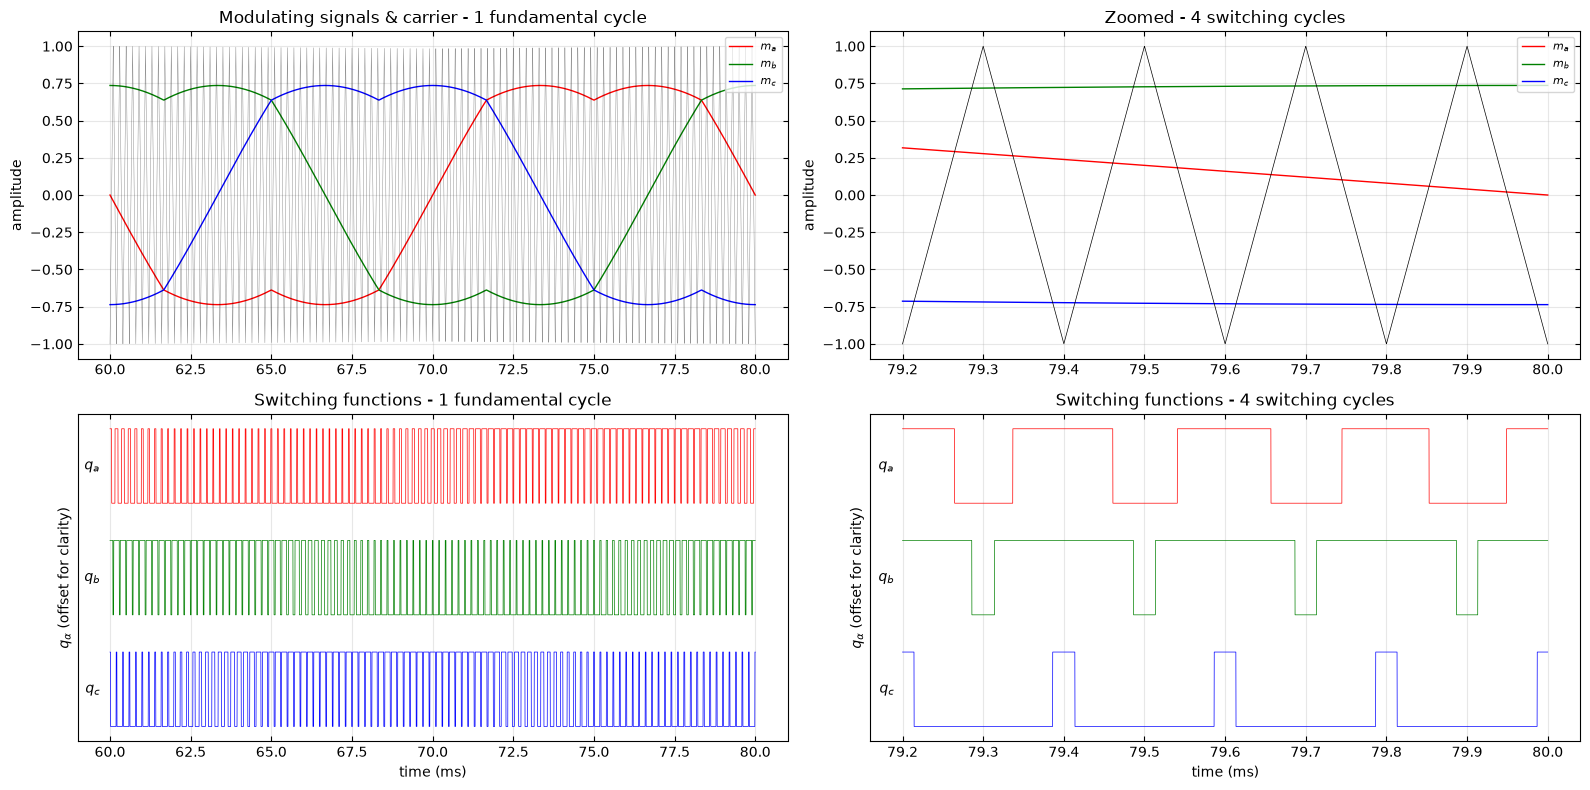

In [5]:
T1  = 1.0 / f1
Tsw = 1.0 / fsw

# Last 1 fundamental cycle
t_fund = np.linspace(t_end - T1, t_end, 12000)
ma_fund = m_a_signal(t_fund)
mb_fund = m_b_signal(t_fund)
mc_fund = m_c_signal(t_fund)
c_fund  = carrier(t_fund)

# Last 4 switching cycles
t_zoom = np.linspace(t_end - 4*Tsw, t_end, 4000)
ma_zoom = m_a_signal(t_zoom)
mb_zoom = m_b_signal(t_zoom)
mc_zoom = m_c_signal(t_zoom)
c_zoom  = carrier(t_zoom)

fig, axs = plt.subplots(2, 2, figsize=(16, 8))

# Top-left: modulating signals + carrier over 1 fundamental cycle
axs[0, 0].plot(t_fund*1000, ma_fund, 'r', lw=1.0, label='$m_a$')
axs[0, 0].plot(t_fund*1000, mb_fund, 'g', lw=1.0, label='$m_b$')
axs[0, 0].plot(t_fund*1000, mc_fund, 'b', lw=1.0, label='$m_c$')
axs[0, 0].plot(t_fund*1000, c_fund,  'k', lw=0.3, alpha=0.5)
axs[0, 0].set_ylabel('amplitude')
axs[0, 0].set_title('Modulating signals & carrier - 1 fundamental cycle')
axs[0, 0].legend(loc='upper right', fontsize=8)

# Top-right: zoomed to 4 switching cycles
axs[0, 1].plot(t_zoom*1000, ma_zoom, 'r', lw=1.0, label='$m_a$')
axs[0, 1].plot(t_zoom*1000, mb_zoom, 'g', lw=1.0, label='$m_b$')
axs[0, 1].plot(t_zoom*1000, mc_zoom, 'b', lw=1.0, label='$m_c$')
axs[0, 1].plot(t_zoom*1000, c_zoom,  'k', lw=0.5)
axs[0, 1].set_ylabel('amplitude')
axs[0, 1].set_title('Zoomed - 4 switching cycles')
axs[0, 1].legend(loc='upper right', fontsize=8)

# Bottom-left: switching functions over 1 fundamental cycle
qa_fund = qa_signal(t_fund)
qb_fund = qb_signal(t_fund)
qc_fund = qc_signal(t_fund)
for i, (q, clr, lbl) in enumerate([(qa_fund, 'r', '$q_a$'), (qb_fund, 'g', '$q_b$'), (qc_fund, 'b', '$q_c$')]):
    axs[1, 0].plot(t_fund*1000, q - 3*i, clr, lw=0.5)
    axs[1, 0].text(t_fund[0]*1000 - 0.3, -3*i, lbl, fontsize=10, ha='right', va='center')
axs[1, 0].set_ylabel('$q_\\alpha$ (offset for clarity)')
axs[1, 0].set_xlabel('time (ms)')
axs[1, 0].set_title('Switching functions - 1 fundamental cycle')
axs[1, 0].set_yticks([])

# Bottom-right: switching functions zoomed
qa_zoom = qa_signal(t_zoom)
qb_zoom = qb_signal(t_zoom)
qc_zoom = qc_signal(t_zoom)
for i, (q, clr, lbl) in enumerate([(qa_zoom, 'r', '$q_a$'), (qb_zoom, 'g', '$q_b$'), (qc_zoom, 'b', '$q_c$')]):
    axs[1, 1].plot(t_zoom*1000, q - 3*i, clr, lw=0.5)
    axs[1, 1].text(t_zoom[0]*1000 - 0.01, -3*i, lbl, fontsize=10, ha='right', va='center')
axs[1, 1].set_ylabel('$q_\\alpha$ (offset for clarity)')
axs[1, 1].set_xlabel('time (ms)')
axs[1, 1].set_title('Switching functions - 4 switching cycles')
axs[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

### Initial Condition Selection

To reduce startup transients, the initial filter currents are estimated from the fundamental-frequency steady-state phasor analysis. Under CSVPWM the peak fundamental phase voltage is $M V_{dc}/2$, so

$$\vec{V}_{\alpha n,1}=\frac{MV_{dc}}{2}e^{j\phi_m},\qquad \vec{V}_{g,\alpha n}=\sqrt{2}\,V_{g,\text{rms}},$$

and the phasor current for each phase is obtained from the single-phase impedance $R_f+j\omega_1 L_f$.

In [6]:
w1 = 2 * np.pi * f1

# Fundamental phasor of converter phase voltage (phase a)
V_an1_phasor = (M * Vdc / 2) * np.exp(1j * phi_m)

# Grid voltage phasor (phase a, cosine reference)
V_ga_phasor  = np.sqrt(2) * Vg_rms * np.exp(1j * 0)

# Steady-state current phasor (phase a)
I_fa_phasor  = (V_an1_phasor - V_ga_phasor) / (Rf + 1j * w1 * Lf)

# Phase b and c are shifted by -120 and +120 degrees
I_fb_phasor  = I_fa_phasor * np.exp(-1j * 2*np.pi/3)
I_fc_phasor  = I_fa_phasor * np.exp(+1j * 2*np.pi/3)

x0 = np.array([np.real(I_fa_phasor), np.real(I_fb_phasor), np.real(I_fc_phasor)])

print(f"Initial currents: i_fa(0) = {x0[0]:.3f} A,  i_fb(0) = {x0[1]:.3f} A,  i_fc(0) = {x0[2]:.3f} A")
print(f"Sum of initial currents: {np.sum(x0):.2e} A (should be approx 0)")

Initial currents: i_fa(0) = 91.172 A,  i_fb(0) = 50.335 A,  i_fc(0) = -141.507 A
Sum of initial currents: 5.68e-14 A (should be approx 0)


### ODE Formulation and Numerical Integration

The three state equations are integrated simultaneously. At each time step, the pole voltages, the common-mode voltage $v_{no}$, and the phase voltages are computed from the switching functions.

$$\frac{di_{f\alpha}}{dt}=\frac{1}{L_f}\left[v_{\alpha n}(t)-R_f\,i_{f\alpha}(t)-v_{g,\alpha n}(t)\right], \qquad \alpha\in\{a,b,c\}.$$

In [7]:
def rhs(t, x):
    i_fa, i_fb, i_fc = x

    qa = qa_signal(t)
    qb = qb_signal(t)
    qc = qc_signal(t)

    # Pole voltages
    v_ao = Vdc / 2 * qa
    v_bo = Vdc / 2 * qb
    v_co = Vdc / 2 * qc

    # Common-mode voltage (midpoint to grid neutral)
    v_no = (v_ao + v_bo + v_co) / 3

    # Phase voltages w.r.t. grid neutral
    v_an = v_ao - v_no
    v_bn = v_bo - v_no
    v_cn = v_co - v_no

    # Grid voltages
    vga = vg_a(t)
    vgb = vg_b(t)
    vgc = vg_c(t)

    # State equations
    di_fa = (v_an - Rf * i_fa - vga) / Lf
    di_fb = (v_bn - Rf * i_fb - vgb) / Lf
    di_fc = (v_cn - Rf * i_fc - vgc) / Lf

    return np.array([di_fa, di_fb, di_fc])

max_step = t_step
sol = solve_ivp(rhs, (t[0], t[-1]), x0, max_step=max_step, dense_output=True)

i_fa = sol.sol(t)[0]
i_fb = sol.sol(t)[1]
i_fc = sol.sol(t)[2]

print(f"Integration completed: {sol.status} ({sol.message})")
print(f"Max |i_fa + i_fb + i_fc| = {np.max(np.abs(i_fa + i_fb + i_fc)):.2e} A (should be approx 0)")

Integration completed: 0 (The solver successfully reached the end of the integration interval.)
Max |i_fa + i_fb + i_fc| = 1.36e-12 A (should be approx 0)


### Waveforms: Filter Currents (AC Side)

The three filter currents $i_{fa}(t)$, $i_{fb}(t)$, $i_{fc}(t)$ are the currents injected into the grid. They are examined at three time scales: the complete simulation, the final two fundamental cycles, and the final four switching cycles.

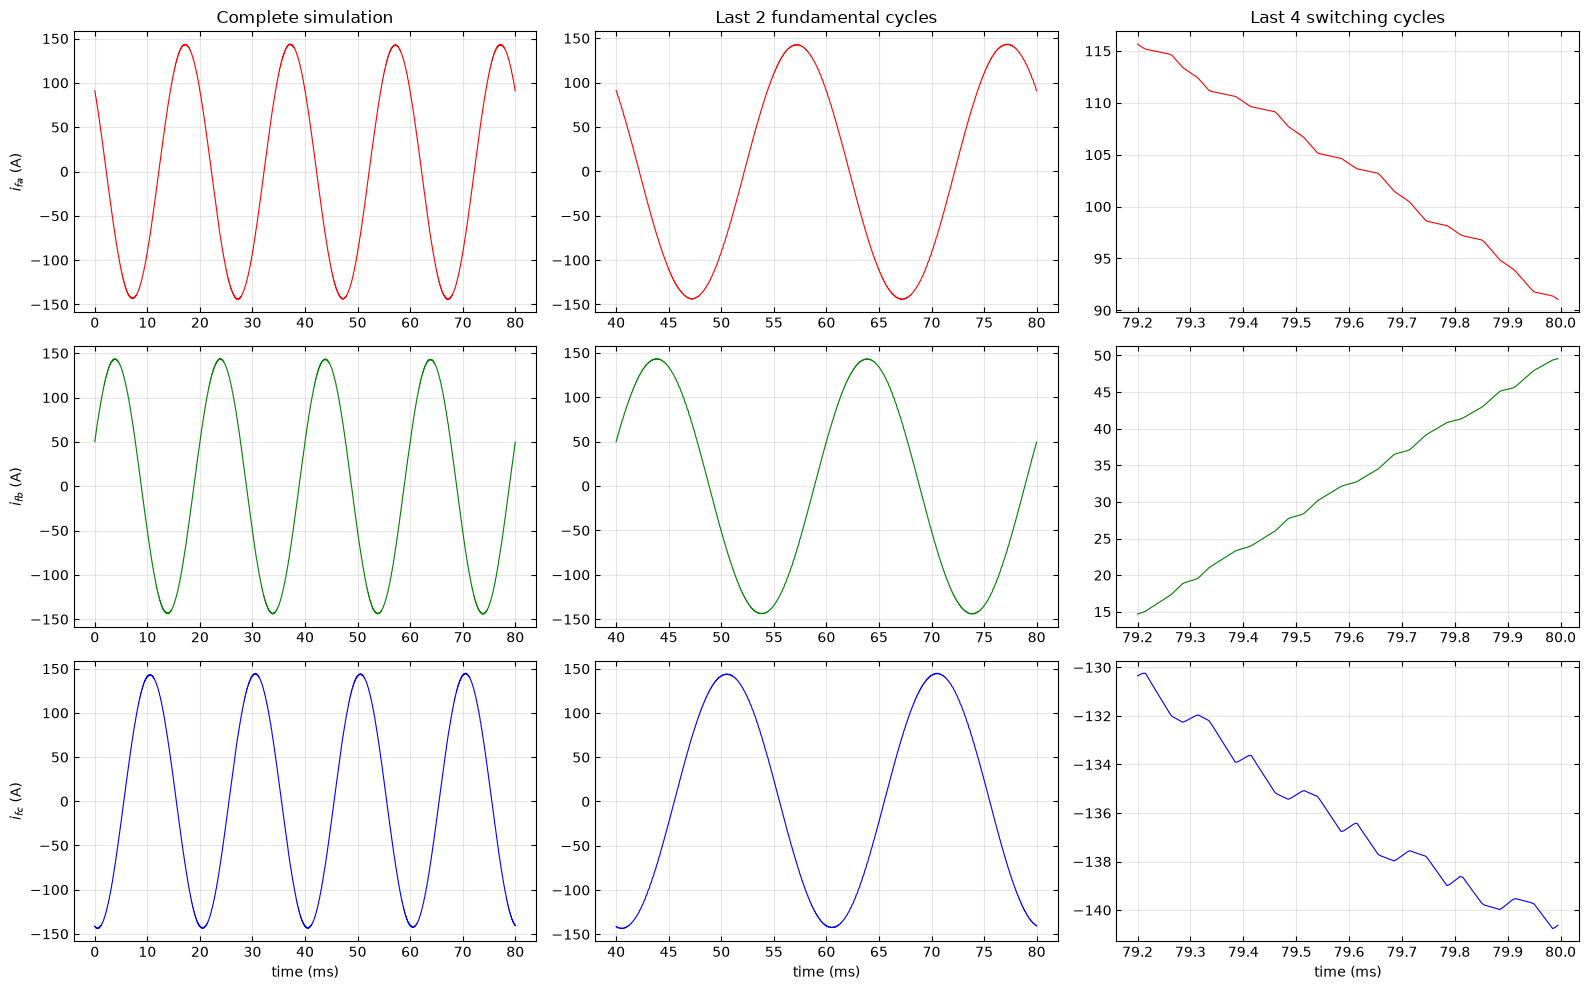

In [8]:
# Time windows
mask_1fund = (t >= (t_end - 1/f1))
mask_2fund = (t >= (t_end - 2/f1))
mask_4sw   = (t >= (t_end - 4/fsw))

fig, axs = plt.subplots(3, 3, figsize=(16, 10))

for row, (i_f, clr, lbl) in enumerate([
    (i_fa, 'red',   '$i_{fa}$'),
    (i_fb, 'green', '$i_{fb}$'),
    (i_fc, 'blue',  '$i_{fc}$'),
]):
    axs[row, 0].plot(t*1000, i_f, color=clr, lw=0.8)
    axs[row, 0].set_ylabel(f'{lbl} (A)')
    if row == 0:
        axs[row, 0].set_title('Complete simulation')

    axs[row, 1].plot(t[mask_2fund]*1000, i_f[mask_2fund], color=clr, lw=0.8)
    if row == 0:
        axs[row, 1].set_title('Last 2 fundamental cycles')

    axs[row, 2].plot(t[mask_4sw]*1000, i_f[mask_4sw], color=clr, lw=0.8)
    if row == 0:
        axs[row, 2].set_title('Last 4 switching cycles')

    if row == 2:
        for col in range(3):
            axs[row, col].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()

### Pole Voltages and Phase Voltages

The pole voltages $v_{\alpha o}=\frac{V_{dc}}{2}q_\alpha$ switch between $\pm V_{dc}/2$. The phase voltages $v_{\alpha n}=v_{\alpha o}-v_{no}$ take five distinct levels $\{0,\,\pm V_{dc}/3,\,\pm 2V_{dc}/3\}$. The phase voltages are the voltages actually applied across the series combination of the filter and the grid.

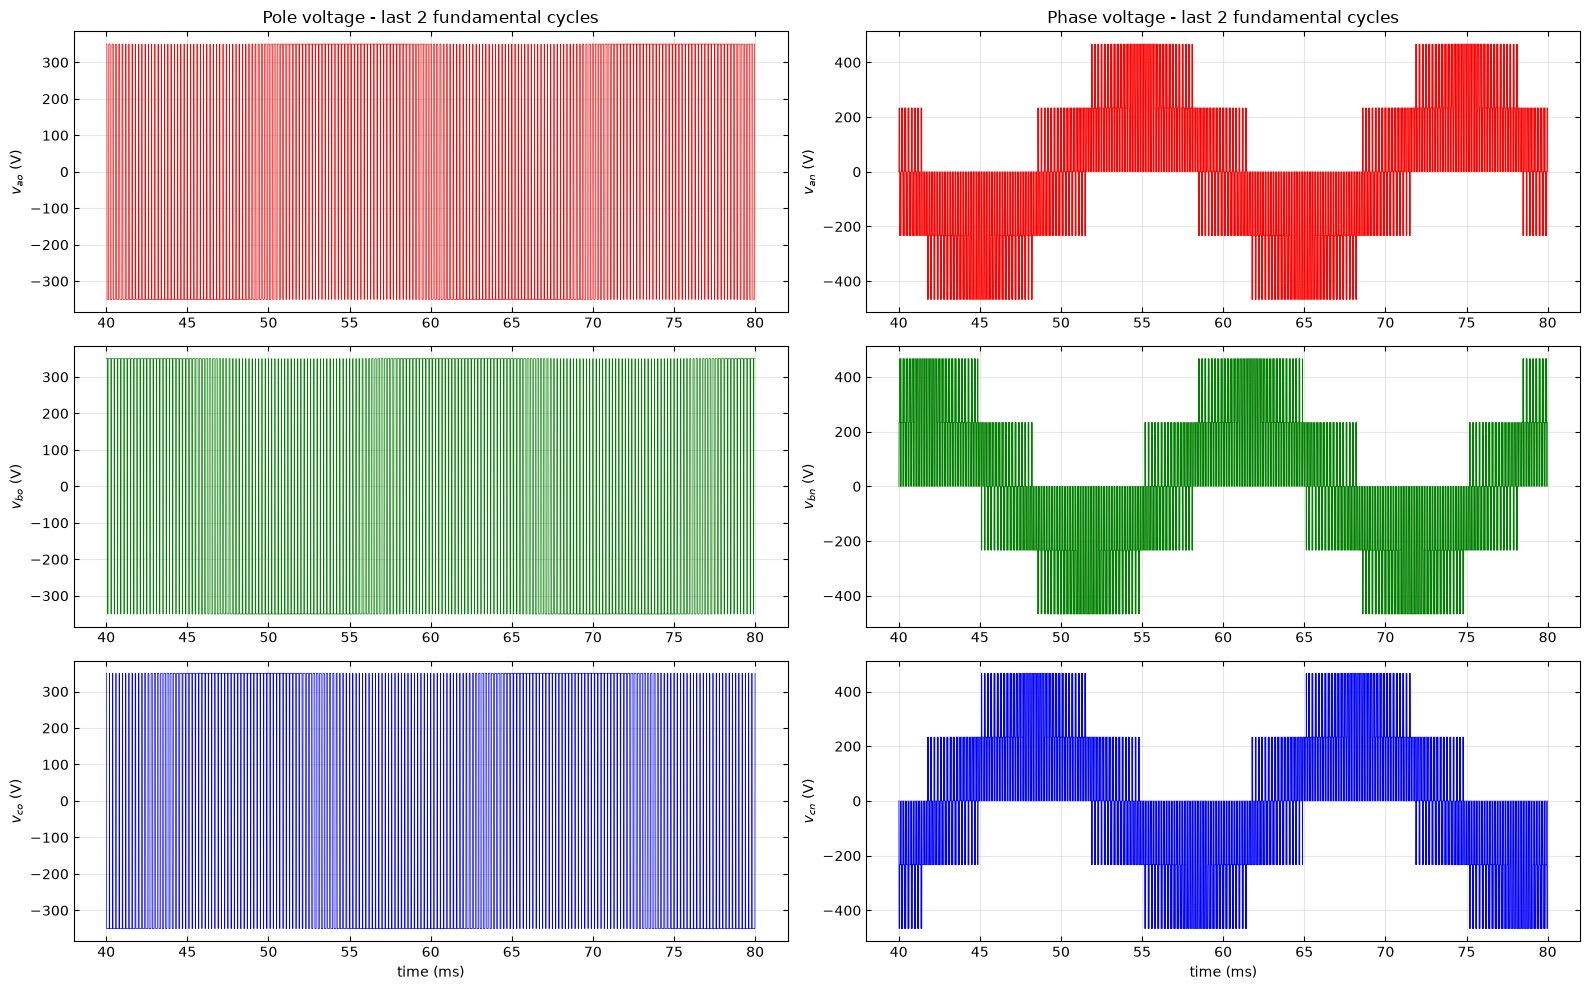

In [9]:
qa_t = qa_signal(t)
qb_t = qb_signal(t)
qc_t = qc_signal(t)

v_ao = Vdc / 2 * qa_t
v_bo = Vdc / 2 * qb_t
v_co = Vdc / 2 * qc_t

v_no = (v_ao + v_bo + v_co) / 3

v_an = v_ao - v_no
v_bn = v_bo - v_no
v_cn = v_co - v_no

fig, axs = plt.subplots(3, 2, figsize=(16, 10))

for row, (v_pole, v_phase, clr, lbl_p, lbl_ph) in enumerate([
    (v_ao, v_an, 'red',   '$v_{ao}$', '$v_{an}$'),
    (v_bo, v_bn, 'green', '$v_{bo}$', '$v_{bn}$'),
    (v_co, v_cn, 'blue',  '$v_{co}$', '$v_{cn}$'),
]):
    axs[row, 0].plot(t[mask_2fund]*1000, v_pole[mask_2fund], color=clr, lw=0.5)
    axs[row, 0].set_ylabel(f'{lbl_p} (V)')
    if row == 0:
        axs[row, 0].set_title('Pole voltage - last 2 fundamental cycles')

    axs[row, 1].plot(t[mask_2fund]*1000, v_phase[mask_2fund], color=clr, lw=0.5)
    axs[row, 1].set_ylabel(f'{lbl_ph} (V)')
    if row == 0:
        axs[row, 1].set_title('Phase voltage - last 2 fundamental cycles')

    if row == 2:
        axs[row, 0].set_xlabel('time (ms)')
        axs[row, 1].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()

### DC-Side Current

The current drawn from the DC source is

$$i_s(t)=\frac{1}{2}\big[q_a(t)\,i_{fa}(t)+q_b(t)\,i_{fb}(t)+q_c(t)\,i_{fc}(t)\big].$$

This waveform is pulsating at the switching frequency. Its local average equals the DC power divided by $V_{dc}$. Instantaneous power balance $\sum_\alpha v_{\alpha o}\,i_{f\alpha}=V_{dc}\,i_s$ is verified numerically.

Max power-balance mismatch |P_ac - P_dc|: 2.91e-11 W


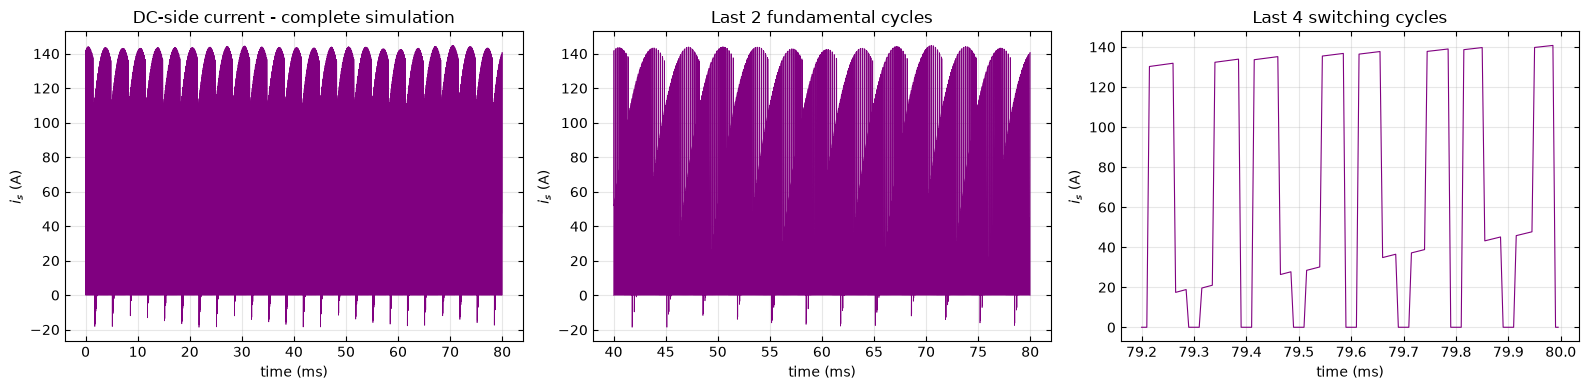

In [10]:
i_s = 0.5 * (qa_t * i_fa + qb_t * i_fb + qc_t * i_fc)

# Verify instantaneous power balance
P_ac = v_ao * i_fa + v_bo * i_fb + v_co * i_fc
P_dc = Vdc * i_s
print(f"Max power-balance mismatch |P_ac - P_dc|: {np.max(np.abs(P_ac - P_dc)):.2e} W")

fig, axs = plt.subplots(1, 3, figsize=(16, 4))

axs[0].plot(t*1000, i_s, color='purple', lw=0.5)
axs[0].set_ylabel('$i_s$ (A)')
axs[0].set_xlabel('time (ms)')
axs[0].set_title('DC-side current - complete simulation')

axs[1].plot(t[mask_2fund]*1000, i_s[mask_2fund], color='purple', lw=0.5)
axs[1].set_ylabel('$i_s$ (A)')
axs[1].set_xlabel('time (ms)')
axs[1].set_title('Last 2 fundamental cycles')

axs[2].plot(t[mask_4sw]*1000, i_s[mask_4sw], color='purple', lw=0.8)
axs[2].set_ylabel('$i_s$ (A)')
axs[2].set_xlabel('time (ms)')
axs[2].set_title('Last 4 switching cycles')

plt.tight_layout()
plt.show()

### Grid-Injected Currents — Overlay with Grid Voltages

The three filter currents are the currents injected into the grid. They are plotted together with the grid voltages (scaled for visibility) to show the phase relationship.

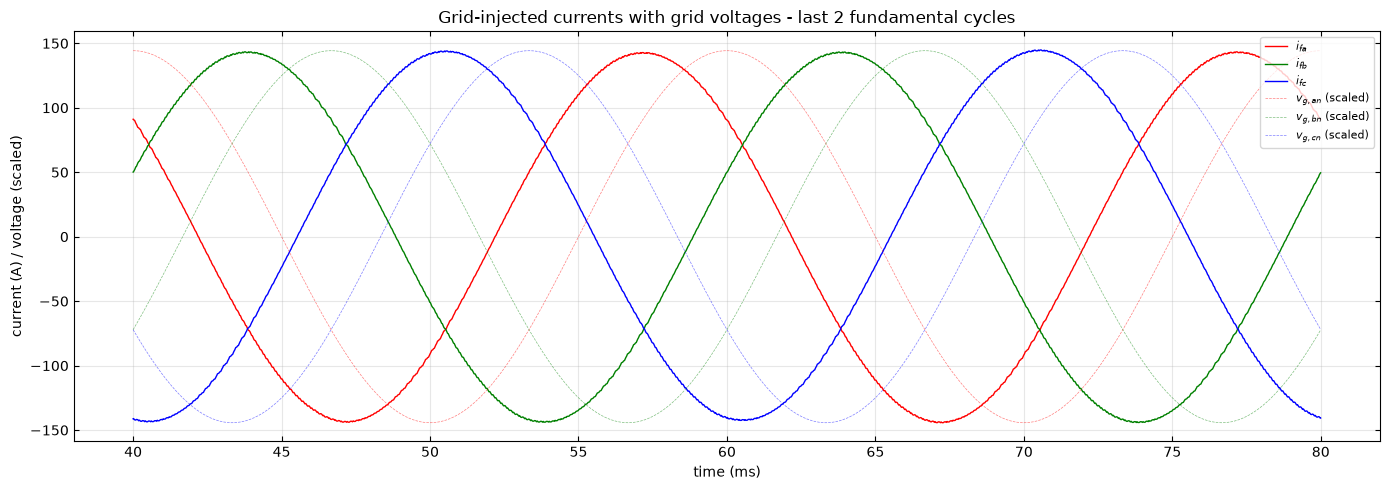

In [11]:
vga_t = vg_a(t)
vgb_t = vg_b(t)
vgc_t = vg_c(t)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Scale grid voltage for overlay
v_scale = np.max(np.abs(i_fa[mask_2fund])) / (np.sqrt(2) * Vg_rms)

ax.plot(t[mask_2fund]*1000, i_fa[mask_2fund], 'r', lw=1.0, label='$i_{fa}$')
ax.plot(t[mask_2fund]*1000, i_fb[mask_2fund], 'g', lw=1.0, label='$i_{fb}$')
ax.plot(t[mask_2fund]*1000, i_fc[mask_2fund], 'b', lw=1.0, label='$i_{fc}$')

ax.plot(t[mask_2fund]*1000, vga_t[mask_2fund]*v_scale, 'r--', lw=0.5, alpha=0.5, label='$v_{g,an}$ (scaled)')
ax.plot(t[mask_2fund]*1000, vgb_t[mask_2fund]*v_scale, 'g--', lw=0.5, alpha=0.5, label='$v_{g,bn}$ (scaled)')
ax.plot(t[mask_2fund]*1000, vgc_t[mask_2fund]*v_scale, 'b--', lw=0.5, alpha=0.5, label='$v_{g,cn}$ (scaled)')

ax.set_xlabel('time (ms)')
ax.set_ylabel('current (A) / voltage (scaled)')
ax.set_title('Grid-injected currents with grid voltages - last 2 fundamental cycles')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### Harmonic Analysis by Discrete Fourier Transform

For harmonic analysis, one steady-state fundamental period, $T_1=1/f_1$, is extracted from each waveform and sampled at $N$ points. The Fourier coefficients are computed using

$$C_k=\frac{1}{N}\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}.$$

Because the analysis window equals one fundamental period, the DFT bin index $k$ is directly the harmonic order $h$.

For real-valued signals, coefficients are converted to a single-sided peak-amplitude spectrum by taking $\hat C_h=2C_h$ for $h>0$. Total harmonic distortion is then evaluated as

$$THD=\frac{\sqrt{\sum_{h\ge 2}|\hat C_h|^2}}{|\hat C_1|}.$$

In [12]:
def dft(signal):
    # Direct DFT via the DFT matrix.
    N = len(signal)
    k = np.arange(N)
    n = np.arange(N)
    W = (1/N) * np.exp(-2j * np.pi * np.outer(k, n) / N)
    return W @ signal

def dft_peak(signal):
    # Single-sided peak-amplitude spectrum for a real-valued signal.
    N = len(signal)
    Ck = dft(signal)
    n_bins = N // 2 + 1
    Ck_p = (2 * Ck[:n_bins]).copy()
    Ck_p[0] /= 2
    if N % 2 == 0:
        Ck_p[-1] /= 2
    return Ck_p

def compute_thd(Ck_p):
    # Total harmonic distortion from the peak-amplitude spectrum.
    fundamental_magnitude = np.abs(Ck_p[1])
    harmonic_magnitudes = np.abs(Ck_p[2:])
    thd = np.sqrt(np.sum(harmonic_magnitudes**2)) / fundamental_magnitude if fundamental_magnitude > 0 else 0
    print("The total harmonic distortion (THD) is {:.2f}%".format(thd * 100))
    return thd

def plot_spectrum(Ck_p, h_max=200, title=None, unit=''):
    # Plot magnitude and phase spectra side by side, vs. harmonic order h.
    h = np.arange(len(Ck_p))
    mask = (h <= h_max)

    mag   = np.abs(Ck_p[mask])
    phase = np.degrees(np.angle(Ck_p[mask]))
    phase[mag < 1e-6*np.max(mag)] = 0.0

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

    axs[0].stem(h[mask], mag, linefmt='tab:blue', markerfmt='o', basefmt=' ')
    axs[0].set_xlabel('harmonic order $h$')
    axs[0].set_ylabel(f'magnitude {unit}')
    axs[0].set_title('Magnitude spectrum' if title is None else f'{title} - magnitude')
    axs[0].set_xlim([0, h_max])

    axs[1].stem(h[mask], phase, linefmt='tab:red', markerfmt='o', basefmt=' ')
    axs[1].set_xlabel('harmonic order $h$')
    axs[1].set_ylabel('phase (deg)')
    axs[1].set_title('Phase spectrum' if title is None else f'{title} - phase')
    axs[1].set_xlim([0, h_max])

    plt.tight_layout()
    plt.show()

### DFT Evaluation Window

The DFT is evaluated with $N=2048$ uniformly spaced samples taken over the final fundamental cycle, which is treated as steady state.

The spectra are plotted up to $h_\text{max}=200$ for the pole voltage $v_{ao}$ and the injected current $i_{fa}$.

PWM scheme: csvpwm, carrier ratio m_f = 100

Pole voltage v_ao:
  fundamental peak = 296.62 V (theoretical M*Vdc/2 = 297.50 V)
The total harmonic distortion (THD) is 133.58%


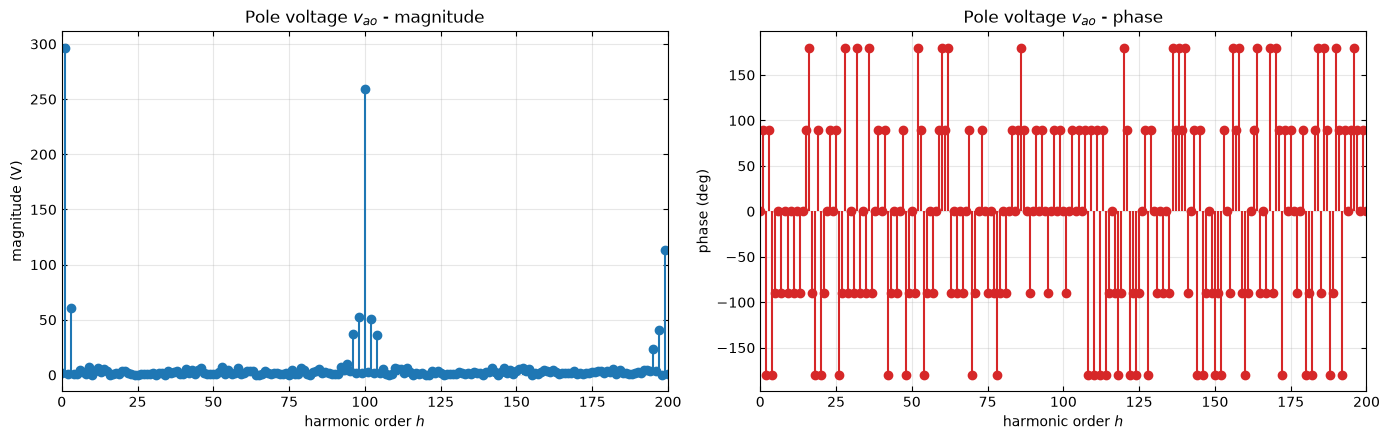


Injected current i_fa:
  fundamental peak = 143.60 A
The total harmonic distortion (THD) is 0.31%


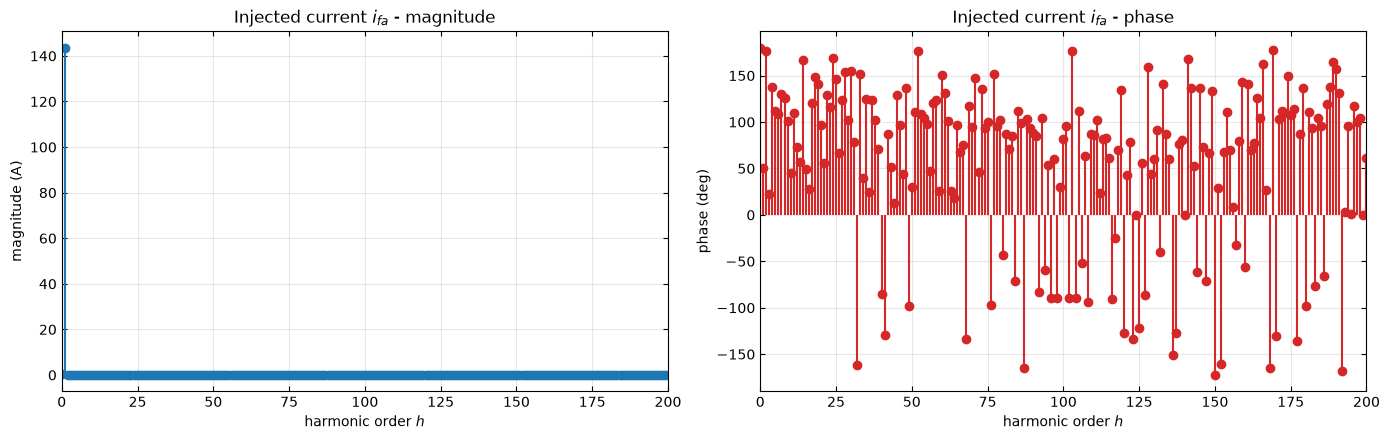

In [13]:
N_dft = 2048
t_window = np.linspace(t_end - 1/f1, t_end, N_dft, endpoint=False)

vao_window = Vdc/2 * qa_signal(t_window)
i_fa_window = sol.sol(t_window)[0]

print(f"PWM scheme: {pwm_mode}, carrier ratio m_f = {m_f:.0f}")
print()

vao_Ck_p = dft_peak(vao_window)
print("Pole voltage v_ao:")
print("  fundamental peak = {:.2f} V (theoretical M*Vdc/2 = {:.2f} V)".format(np.abs(vao_Ck_p[1]), M*Vdc/2))
compute_thd(vao_Ck_p)
plot_spectrum(vao_Ck_p, h_max=200, title='Pole voltage $v_{ao}$', unit='(V)')

i_fa_Ck_p = dft_peak(i_fa_window)
print()
print("Injected current i_fa:")
print("  fundamental peak = {:.2f} A".format(np.abs(i_fa_Ck_p[1])))
compute_thd(i_fa_Ck_p)
plot_spectrum(i_fa_Ck_p, h_max=200, title='Injected current $i_{fa}$', unit='(A)')

### Credits and Disclaimer

This notebook is part of the NPTEL course *Grid Connected Power Converters - Operating Principles*.

The simulation ideas, modelling approach, and technical interpretation in this notebook are original to the author.

This notebook presents an idealized three-phase converter model. It assumes a constant DC link and other simplifying idealizations that are appropriate for pedagogical study of waveforms and harmonic content. The results are therefore useful for understanding the operating principle and analysis method, but they are not a substitute for detailed converter design validation.

AI assistance was used only to polish and refine portions of the code structure and documentation language.